# EDA Completo - Customer Support Ticket Dataset

**Projeto de Bloco: Análise e Segurança de Agentes de IA - TP2**

# Documentação do Dataset

## 1. Fonte

O dataset é o **Customer Support Ticket Dataset**, publicado por *suraj520* no Kaggle em 02/06/2023, disponível em https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset. Ele reúne cerca de 8,5 mil tickets de atendimento sobre produtos de tecnologia (celulares, notebooks, fones, eletrodomésticos inteligentes, etc.), com dados do cliente, do produto, do próprio ticket e de métricas de atendimento.

**Licença de uso:** CC0: Public Domain (livre para uso educacional e comercial sem restrições).
**Data de acesso:** Setembro de 2026.

É um dataset **sintético**, ou seja, os registros foram gerados artificialmente e não vêm de um sistema real de atendimento. Isso aparece na inspeção dos dados, porque a descrição dos tickets vem com marcadores de template que nunca foram preenchidos e todos os e-mails usam domínios fictícios (`example.com`, `.net`, `.org`). A verificação de qualidade detalha esses pontos.

## 2. Principais características

* São **8.469 registros** e **17 colunas**, onde cada linha é uma solicitação de um cliente.
* As colunas cobrem quatro blocos: identificação do cliente (nome, e-mail, idade, gênero), o produto comprado e a data da compra, o ticket em si (tipo, assunto, descrição, status, prioridade, canal) e as métricas de atendimento (primeira resposta, tempo de resolução, resolução e nota de satisfação).
* Existem duas colunas que podem servir de alvo, `Ticket Type` (5 categorias) e `Ticket Subject` (16 categorias), as duas descrevendo o motivo do contato.
* Boa parte das métricas de atendimento só existe para tickets já fechados, então elas aparecem vazias na maioria dos registros por causa do ciclo de vida do ticket, não por erro.
* A coluna de descrição, que seria a "mensagem" do cliente, está preenchida com marcadores de template não substituídos, então ela não é utilizável como texto direto.

## 3. Motivo da escolha

Esse dataset encaixa no domínio de um sistema de atendimento ao cliente, porque cada linha é uma solicitação de suporte com o motivo do contato já rotulado. Isso permite tratar o problema como uma classificação de intenção. As perguntas que ele consegue responder são do tipo "qual é a intenção por trás desse contato?" e "como os tipos de solicitação se distribuem entre produtos, canais e perfis de cliente?".

Vale registrar uma limitação do dataset. Por ser sintético, ele funciona bem para praticar todo o fluxo de EDA e de construção da API, mas não representa um caso real, então serve mais como base de estudo do que como fonte para um modelo de produção.

# **Importação de Bibliotecas e Carregamento dos Dados**

In [6]:
import os
import shutil
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import unicodedata

caminho_csv = "data/customer_support_tickets.csv"

print(f"Carregando dataset a partir de: {caminho_csv}")
df = pd.read_csv(caminho_csv)

def print_formatado(*args, prefixo=5, largura_total=100):
  titulo = " ".join(str(a) for a in args)
  print("\n")
  print("=" * 100)
  print(titulo)
  print("=" * 100)

Carregando dataset a partir de: data/customer_support_tickets.csv


# **1.1. Compreensão do Problema e do Dataset**

In [7]:
print_formatado("Compreensão do problema e do dataset:")
print("Ver Markdown")



Compreensão do problema e do dataset:
Ver Markdown


## **Observações Compreensão do Problema e do Dataset**

* **Domínio do problema:** classificar automaticamente a intenção de um cliente a partir dos dados do seu ticket de atendimento. É um problema de classificação com mais de duas classes.
* **Coluna-alvo:** `Ticket Type`, que já traz a intenção do contato em cinco categorias limpas (`Refund request`, `Technical issue`, `Cancellation request`, `Product inquiry`, `Billing inquiry`). A gente preferiu ela no lugar de `Ticket Subject` porque o Subject tem 16 categorias e funciona mais como tópico do que como intenção.
* **Variáveis candidatas a preditoras:** os atributos estruturados do ticket e do cliente, como produto comprado, canal, prioridade, idade e gênero.
* **O que seria uma solução:** um classificador que, recebendo os dados de um ticket, devolve a intenção mais provável, encaminhando o cliente para o fluxo de atendimento certo.
* **Ponto de atenção já nesta fase:** a descrição do ticket seria a fonte natural de texto, mas ela está preenchida com marcadores de template não substituídos, então não dá pra usar como mensagem. A gente detalha isso na verificação de qualidade.

# **1.2. Inspeção Inicial**

In [8]:
print_formatado("1. Tamanho do dataset:")
print(df.shape)



1. Tamanho do dataset:
(8469, 17)


In [9]:
print_formatado("2. Variáveis do dataset:")
print(df.columns)



2. Variáveis do dataset:
Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')


In [10]:
print_formatado("3. Significado das colunas:")
print("Ver Markdown")



3. Significado das colunas:
Ver Markdown


In [11]:
print_formatado("4. Tipos dos dados:")
print(df.dtypes)



4. Tipos dos dados:
Ticket ID                         int64
Customer Name                    object
Customer Email                   object
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution                       object
Ticket Priority                  object
Ticket Channel                   object
First Response Time              object
Time to Resolution               object
Customer Satisfaction Rating    float64
dtype: object


In [12]:
print_formatado("5. Organização dos registros:")
df.info()
print("Ver Markdown")



5. Organização dos registros:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               

In [13]:
print_formatado("6. Exemplo de valores:")
print("\nPrimeiros registros:")
print(df.head())

print("\nÚltimos registros:")
print(df.tail())

print("\nRegistros aleatórios:")
print(df.sample(5, random_state=1))

print("\nExemplo dataset:")
display(df)



6. Exemplo de valores:

Primeiros registros:
   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0       

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaN,NaN,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0


In [14]:
print_formatado("7. Identificação das variáveis")

colunas_numericas = ["Customer Age", "Customer Satisfaction Rating"]
colunas_categoricas = ["Customer Gender", "Product Purchased", "Ticket Type",
                       "Ticket Subject", "Ticket Status", "Ticket Priority", "Ticket Channel"]
colunas_textuais = ["Customer Name", "Customer Email", "Ticket Description", "Resolution"]
colunas_temporais = ["Date of Purchase", "First Response Time", "Time to Resolution"]

print("\nVariáveis numéricas:")
for coluna in colunas_numericas:
    print(f"{coluna}: min={df[coluna].min()}, max={df[coluna].max()}, média={df[coluna].mean():.2f}")

print("\nVariáveis categóricas:")
for coluna in colunas_categoricas:
    print(f"{coluna} ({df[coluna].nunique()} categorias): {df[coluna].unique().tolist()}")

print("\nVariáveis textuais:")
for coluna in colunas_textuais:
    print(f"{coluna}: exemplo -> {str(df[coluna].dropna().iloc[0])[:80]}")

print("\nVariáveis temporais:")
for coluna in colunas_temporais:
    datas = pd.to_datetime(df[coluna], errors="coerce")
    print(f"{coluna}: de {datas.min()} até {datas.max()}")



7. Identificação das variáveis

Variáveis numéricas:
Customer Age: min=18, max=70, média=44.03
Customer Satisfaction Rating: min=1.0, max=5.0, média=2.99

Variáveis categóricas:
Customer Gender (3 categorias): ['Other', 'Female', 'Male']
Product Purchased (42 categorias): ['GoPro Hero', 'LG Smart TV', 'Dell XPS', 'Microsoft Office', 'Autodesk AutoCAD', 'Microsoft Surface', 'Philips Hue Lights', 'Fitbit Versa Smartwatch', 'Dyson Vacuum Cleaner', 'Nintendo Switch', 'Microsoft Xbox Controller', 'Nintendo Switch Pro Controller', 'Nest Thermostat', 'Sony PlayStation', 'GoPro Action Camera', 'Xbox', 'LG Washing Machine', 'Canon EOS', 'HP Pavilion', 'Amazon Kindle', 'Lenovo ThinkPad', 'Fitbit Charge', 'Adobe Photoshop', 'Google Pixel', 'Amazon Echo', 'PlayStation', 'Samsung Galaxy', 'iPhone', 'LG OLED', 'Sony Xperia', 'Apple AirPods', 'Sony 4K HDR TV', 'Canon DSLR Camera', 'Roomba Robot Vacuum', 'Nikon D', 'Bose QuietComfort', 'Samsung Soundbar', 'Asus ROG', 'Bose SoundLink Speaker', 'Googl

In [15]:
print_formatado("8. Variáveis relevantes para o objetivo da análise")
print("Ver Markdown")



8. Variáveis relevantes para o objetivo da análise
Ver Markdown


In [16]:
print_formatado("9. Possíveis problemas nos dados")
print("Ver Markdown")



9. Possíveis problemas nos dados
Ver Markdown


## **Observações Inspeção Inicial**

### 3. Significado das colunas

* **Ticket ID:** identificador único do ticket. Não é preditor, serve só de chave.
* **Customer Name:** nome do cliente. Texto livre, sem valor preditivo e com dado pessoal.
* **Customer Email:** e-mail do cliente. Todos usam domínios fictícios (`example.com`, `.net`, `.org`), coerente com dado sintético.
* **Customer Age:** idade do cliente, de 18 a 70 anos.
* **Customer Gender:** gênero do cliente (`Male`, `Female`, `Other`).
* **Product Purchased:** produto sobre o qual é o ticket, com 42 produtos de tecnologia.
* **Date of Purchase:** data da compra, entre 2020 e 2021.
* **Ticket Type:** tipo do ticket, em 5 categorias. É a nossa coluna-alvo.
* **Ticket Subject:** assunto do ticket, em 16 categorias. Segunda candidata a alvo.
* **Ticket Description:** descrição do problema. Deveria ser a mensagem do cliente, mas está com marcadores de template não preenchidos.
* **Ticket Status:** situação do ticket (`Open`, `Pending Customer Response`, `Closed`).
* **Resolution:** texto da resolução, preenchido só em tickets fechados.
* **Ticket Priority:** prioridade (`Low`, `Medium`, `High`, `Critical`).
* **Ticket Channel:** canal do contato (`Email`, `Phone`, `Chat`, `Social media`).
* **First Response Time:** momento da primeira resposta, vazio enquanto o ticket está aberto.
* **Time to Resolution:** momento da resolução, preenchido só em tickets fechados.
* **Customer Satisfaction Rating:** nota de 1 a 5 dada pelo cliente, só em tickets fechados.

### 5. Organização dos registros

* O dataset tem 8.469 registros e 17 colunas.
* O `df.info()` mostra colunas com contagem de não-nulos menor que o total, e isso vem das métricas de atendimento que só existem para tickets fechados, não de erro de carregamento.
* Os tipos foram lidos certos pelo pandas, com numéricas como `int64`/`float64`, e o resto como `object`. As colunas de data vieram como `object` e vão precisar virar datetime na limpeza.

### 6. Exemplo de valores

* Já dá pra ver nos exemplos que a `Ticket Description` está com o marcador `{product_purchased}` sem substituição, o que confirma o problema do texto.

### 7. Identificação das variáveis

* **Numéricas:** `Customer Age` e `Customer Satisfaction Rating`. O `Ticket ID` é inteiro, mas é identificador, então não conta como numérica de análise.
* **Categóricas:** `Customer Gender`, `Product Purchased`, `Ticket Type`, `Ticket Subject`, `Ticket Status`, `Ticket Priority` e `Ticket Channel`.
* **Textuais livres:** `Customer Name`, `Customer Email`, `Ticket Description` e `Resolution`.
* **Temporais:** `Date of Purchase`, `First Response Time` e `Time to Resolution`.

### 8. Variáveis relevantes para o objetivo da análise

* **Ticket Type** é o alvo.
* As candidatas a preditoras são os atributos estruturados do ticket e do cliente, como `Product Purchased`, `Ticket Channel`, `Ticket Priority`, `Customer Age` e `Customer Gender`.
* As métricas de atendimento (`Resolution`, `Time to Resolution`, `First Response Time`, `Customer Satisfaction Rating`) são resultados que só existem depois do atendimento, então não servem para prever a intenção no momento em que o ticket chega.
* `Ticket ID`, `Customer Name` e `Customer Email` são identificação e não entram como preditoras.

### 9. Possíveis problemas nos dados

* A `Ticket Description` está com marcadores de template não substituídos em todos os registros, então o texto não é utilizável direto.
* Várias colunas têm muitos valores vazios por causa do ciclo de vida do ticket, o que precisa ser interpretado como estado e não como erro.
* Há sinais de que o dataset é sintético, como e-mails com domínios fictícios e horários de primeira resposta e resolução concentrados num intervalo de dois dias de 2023. Isso não atrapalha o EDA, mas limita o dataset como base de um modelo real.

# **1.3. Verificação da Qualidade dos Dados**

In [17]:
colunas_categoricas = ["Customer Gender", "Product Purchased", "Ticket Type",
                       "Ticket Subject", "Ticket Status", "Ticket Priority", "Ticket Channel"]

print_formatado("1. Valores ausentes:")
print("Valores ausentes (NaN) por coluna:")
print(df.isnull().sum())

print("\nValores ausentes (%):")
print((df.isnull().mean() * 100).round(2))

print("\nAusentes por Ticket Status (colunas de atendimento):")
for coluna in ["Resolution", "Time to Resolution", "Customer Satisfaction Rating", "First Response Time"]:
    print(f"\n{coluna}:")
    print(df.groupby("Ticket Status")[coluna].apply(lambda s: s.isnull().sum()))
print("Ver Markdown")



1. Valores ausentes:
Valores ausentes (NaN) por coluna:
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

Valores ausentes (%):
Ticket ID                        0.00
Customer Name                    0.00
Customer Email                   0.00
Customer Age                     0.00
Customer Gender                  0.00
Product Purchased                0.00
Date of Purchase                 0.00
Ticket Type

In [18]:
print_formatado("2. Registros duplicados:")
print("Duplicatas completas:")
print(df.duplicated().sum())

print("\nDuplicatas desconsiderando Ticket ID:")
print(df.drop(columns=["Ticket ID"]).duplicated().sum())
print("Ver Markdown")



2. Registros duplicados:
Duplicatas completas:
0

Duplicatas desconsiderando Ticket ID:
0
Ver Markdown


In [19]:
print_formatado("3. Tipos de dados:")
print("Tipo predominante por coluna:")
for coluna in df:
    print(f"{coluna:<30}: {df[coluna].apply(type).value_counts().index[0]}")

print("\nQuantidade de categorias por coluna:")
for coluna in df:
    print(f"{coluna:<30}: {df[coluna].nunique()}")
print("Ver Markdown")



3. Tipos de dados:
Tipo predominante por coluna:
Ticket ID                     : <class 'int'>
Customer Name                 : <class 'str'>
Customer Email                : <class 'str'>
Customer Age                  : <class 'int'>
Customer Gender               : <class 'str'>
Product Purchased             : <class 'str'>
Date of Purchase              : <class 'str'>
Ticket Type                   : <class 'str'>
Ticket Subject                : <class 'str'>
Ticket Description            : <class 'str'>
Ticket Status                 : <class 'str'>
Resolution                    : <class 'float'>
Ticket Priority               : <class 'str'>
Ticket Channel                : <class 'str'>
First Response Time           : <class 'str'>
Time to Resolution            : <class 'float'>
Customer Satisfaction Rating  : <class 'float'>

Quantidade de categorias por coluna:
Ticket ID                     : 8469
Customer Name                 : 8028
Customer Email                : 8320
Customer Age

In [20]:
print_formatado("4. Categorias escritas de maneira diferente:")
def normalizar_texto(valor):
    if pd.isna(valor):
        return valor
    valor = valor.strip().lower()
    valor = (
        unicodedata.normalize("NFKD", valor)
        .encode("ASCII", "ignore")
        .decode("utf-8")
    )
    return valor

for coluna in colunas_categoricas:
    com_normalizacao = df[coluna].apply(normalizar_texto).nunique()
    sem_normalizacao = df[coluna].nunique()
    print(f"{coluna:<20} -> Com Normalização: {com_normalizacao} | Sem Normalização: {sem_normalizacao}")



4. Categorias escritas de maneira diferente:
Customer Gender      -> Com Normalização: 3 | Sem Normalização: 3
Product Purchased    -> Com Normalização: 42 | Sem Normalização: 42
Ticket Type          -> Com Normalização: 5 | Sem Normalização: 5
Ticket Subject       -> Com Normalização: 16 | Sem Normalização: 16
Ticket Status        -> Com Normalização: 3 | Sem Normalização: 3
Ticket Priority      -> Com Normalização: 4 | Sem Normalização: 4
Ticket Channel       -> Com Normalização: 4 | Sem Normalização: 4


In [21]:
print_formatado("5. Textos vazios ou espaços extras:")
colunas_texto_total = colunas_categoricas + colunas_textuais
for coluna in colunas_texto_total:
    if coluna in df.columns:
        serie = df[coluna].dropna().astype(str)
        qtd_espacos = (serie != serie.str.strip()).sum()
        vazios = (serie.str.strip() == "").sum()
        print(f"{coluna:<30}: espaços nas bordas = {qtd_espacos} | vazios (len 0) = {vazios}")



5. Textos vazios ou espaços extras:
Customer Gender               : espaços nas bordas = 0 | vazios (len 0) = 0
Product Purchased             : espaços nas bordas = 0 | vazios (len 0) = 0
Ticket Type                   : espaços nas bordas = 0 | vazios (len 0) = 0
Ticket Subject                : espaços nas bordas = 0 | vazios (len 0) = 0
Ticket Status                 : espaços nas bordas = 0 | vazios (len 0) = 0
Ticket Priority               : espaços nas bordas = 0 | vazios (len 0) = 0
Ticket Channel                : espaços nas bordas = 0 | vazios (len 0) = 0
Customer Name                 : espaços nas bordas = 0 | vazios (len 0) = 0
Customer Email                : espaços nas bordas = 0 | vazios (len 0) = 0
Ticket Description            : espaços nas bordas = 0 | vazios (len 0) = 0
Resolution                    : espaços nas bordas = 0 | vazios (len 0) = 0


In [22]:
print_formatado("6. Valores impossíveis ou fora do contexto:")
print("Customer Age:")
print(f"  mínimo: {df['Customer Age'].min()} | máximo: {df['Customer Age'].max()}")
print(f"  fora de 18 a 100: {df['Customer Age'][(df['Customer Age'] < 18) | (df['Customer Age'] > 100)].count()}")

print("\nCustomer Satisfaction Rating:")
print(f"  valores encontrados: {sorted(df['Customer Satisfaction Rating'].dropna().unique().tolist())}")
print(f"  fora de 1 a 5: {df['Customer Satisfaction Rating'][(df['Customer Satisfaction Rating'] < 1) | (df['Customer Satisfaction Rating'] > 5)].count()}")

print("\nDatas parseáveis (sem falha de conversão):")
for coluna in ["Date of Purchase", "First Response Time", "Time to Resolution"]:
    parsed = pd.to_datetime(df[coluna], errors="coerce")
    falhas = parsed.isna().sum() - df[coluna].isna().sum()
    print(f"  {coluna:<22}: falhas={falhas} | de {parsed.min()} até {parsed.max()}")



6. Valores impossíveis ou fora do contexto:
Customer Age:
  mínimo: 18 | máximo: 70
  fora de 18 a 100: 0

Customer Satisfaction Rating:
  valores encontrados: [1.0, 2.0, 3.0, 4.0, 5.0]
  fora de 1 a 5: 0

Datas parseáveis (sem falha de conversão):
  Date of Purchase      : falhas=0 | de 2020-01-01 00:00:00 até 2021-12-30 00:00:00
  First Response Time   : falhas=0 | de 2023-05-31 21:55:39 até 2023-06-02 00:54:21
  Time to Resolution    : falhas=0 | de 2023-05-31 21:53:30 até 2023-06-02 00:55:33


In [23]:
print_formatado("7. Erros de digitação ou preenchimento:")

print("Marcadores de template não preenchidos na Ticket Description:")
placeholder = df["Ticket Description"].str.contains(r"\{.*?\}", regex=True, na=False)
print(f"  descrições com marcador {{...}}: {placeholder.sum()} ({placeholder.mean() * 100:.1f}%)")

print("")
print("Inconsistência de capitalização nas categóricas:")
for coluna in colunas_categoricas:
    if df[coluna].nunique() != df[coluna].str.lower().nunique():
        print(f"  {coluna}: há diferença de caixa")
    else:
        print(f"  {coluna}: sem inconsistência de capitalização")

print("")
print("Caracteres inesperados nas categóricas (fora de letras, espaço, hífen e '&'):")
for coluna in colunas_categoricas:
    padrao = r"[^A-Za-z\s\-&]"
    estranhos = df[coluna][df[coluna].str.contains(padrao, na=False, regex=True)].unique()
    if len(estranhos) > 0:
        print(f"  {coluna}: {list(estranhos)}")
    else:
        print(f"  {coluna}: nenhum caractere inesperado")



7. Erros de digitação ou preenchimento:
Marcadores de template não preenchidos na Ticket Description:
  descrições com marcador {...}: 8469 (100.0%)

Inconsistência de capitalização nas categóricas:
  Customer Gender: sem inconsistência de capitalização
  Product Purchased: sem inconsistência de capitalização
  Ticket Type: sem inconsistência de capitalização
  Ticket Subject: sem inconsistência de capitalização
  Ticket Status: sem inconsistência de capitalização
  Ticket Priority: sem inconsistência de capitalização
  Ticket Channel: sem inconsistência de capitalização

Caracteres inesperados nas categóricas (fora de letras, espaço, hífen e '&'):
  Customer Gender: nenhum caractere inesperado
  Product Purchased: ['Sony 4K HDR TV']
  Ticket Type: nenhum caractere inesperado
  Ticket Subject: nenhum caractere inesperado
  Ticket Status: nenhum caractere inesperado
  Ticket Priority: nenhum caractere inesperado
  Ticket Channel: nenhum caractere inesperado


In [24]:
print_formatado("8. Problemas que precisam ser corrigidos antes da análise:")
print("Ver Markdown")



8. Problemas que precisam ser corrigidos antes da análise:
Ver Markdown


## **Observações Qualidade dos Dados**

### 1. Valores ausentes e em qual quantidade
* Não há ausentes nas colunas de cliente, produto e nos rótulos (`Ticket Type` e `Ticket Subject` estão completos).
* As ausências se concentram nas métricas de atendimento, `Resolution` (67,3%), `Time to Resolution` (67,3%), `Customer Satisfaction Rating` (67,3%) e `First Response Time` (33,3%).
* Cruzando com `Ticket Status`, dá pra ver que essas ausências são **estruturais**. `Resolution`, `Time to Resolution` e `Customer Satisfaction Rating` só existem em tickets `Closed`, e `First Response Time` some só nos tickets `Open`. Ou seja, o vazio representa um estado do ticket, não dado perdido.
* **Decisão:** manter as ausências, porque preencher com "Desconhecido" ou remover as linhas destruiria informação e não faz sentido inventar uma resolução para um ticket que ainda não foi resolvido.

### 2. Registros duplicados
* Não há duplicatas completas nem duplicatas desconsiderando o `Ticket ID`, então nenhuma remoção é necessária.

### 3. Tipos dos dados
* As numéricas e o `Ticket ID` vieram corretas. As categóricas estão como `object` e vão virar `category`. As três colunas de data estão como `object` e precisam virar datetime.

### 4. Categorias escritas de forma diferente
* Nenhuma variável categórica muda de contagem depois da normalização, então não há grafias diferentes para a mesma categoria.

### 5. Textos vazios ou espaços extras
* A auditoria estendida cobrindo variáveis categóricas e textuais confirmou que não há textos vazios ou preenchidos apenas com espaços em branco após o tratamento das ausências estruturais.

### 6. Valores impossíveis ou fora de contexto
* `Customer Age` fica entre 18 e 70, dentro do esperado.
* `Customer Satisfaction Rating` só assume valores de 1 a 5, coerente com a escala.
* As três colunas de data são convertíveis sem falha. Vale notar que `First Response Time` e `Time to Resolution` caem todas num intervalo de dois dias de 2023, enquanto a compra é de 2020 e 2021, o que reforça que esses timestamps são artefato da geração sintética e não têm valor analítico.

### 7. Erros de digitação ou preenchimento
* O problema grave está na `Ticket Description`. Todos os registros contêm marcadores de template não substituídos, como `{product_purchased}`, e muitos ainda misturam fragmentos de código e texto sem sentido. O texto não serve como mensagem do cliente.
* Não há inconsistência de capitalização nem caractere inesperado nas categóricas.

### 8. Problemas que precisam ser corrigidos antes da análise
* Converter as categóricas para `category` e as datas para datetime.
* Manter as ausências estruturais das métricas de atendimento, documentando que representam o estado do ticket.
* Tratar a `Ticket Description` como não utilizável enquanto texto e não usá-la como preditora nesta etapa.
* Registrar que os timestamps de atendimento são artefato e não entram na análise.

# **1.4. Limpeza e Preparação dos Dados**

In [25]:
print_formatado("1. Remover/tratar registros duplicados desnecessários:")
print(f"Duplicatas completas antes: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Duplicatas completas depois: {df.duplicated().sum()}")
print("Nenhuma duplicata a remover neste dataset.")



1. Remover/tratar registros duplicados desnecessários:
Duplicatas completas antes: 0
Duplicatas completas depois: 0
Nenhuma duplicata a remover neste dataset.


In [26]:
print_formatado("2. Remover/tratar valores ausentes de forma justificada:")
print("Ausências por coluna (mantidas, pois são estruturais):")
colunas_atendimento = ["First Response Time", "Time to Resolution", "Resolution", "Customer Satisfaction Rating"]
for coluna in colunas_atendimento:
    print(f"{coluna:<30}: {df[coluna].isnull().sum()} ausentes")
print("\nDecisão: manter as ausências, pois representam o ciclo de vida do ticket (só existem quando o ticket avança/fecha).")
print("Ver Markdown")



2. Remover/tratar valores ausentes de forma justificada:
Ausências por coluna (mantidas, pois são estruturais):
First Response Time           : 2819 ausentes
Time to Resolution            : 5700 ausentes
Resolution                    : 5700 ausentes
Customer Satisfaction Rating  : 5700 ausentes

Decisão: manter as ausências, pois representam o ciclo de vida do ticket (só existem quando o ticket avança/fecha).
Ver Markdown


In [27]:
print_formatado("3. Corrigir tipos das colunas:")
colunas_categoricas = ["Customer Gender", "Product Purchased", "Ticket Type",
                       "Ticket Subject", "Ticket Status", "Ticket Priority", "Ticket Channel"]
colunas_data = ["Date of Purchase", "First Response Time", "Time to Resolution"]

print("Tipos antes da conversão:")
print(df[colunas_categoricas + colunas_data].dtypes)

for coluna in colunas_categoricas:
    df[coluna] = df[coluna].astype("category")
for coluna in colunas_data:
    df[coluna] = pd.to_datetime(df[coluna], errors="coerce")

# Criacao de metrica textual para subsidiar a analise multivariada e testes formais do TP2
df["ticket_word_count"] = df["Ticket Description"].astype(str).apply(lambda x: len(x.split()))

print("\nTipos depois da conversão:")
print(df[colunas_categoricas + colunas_data].dtypes)



3. Corrigir tipos das colunas:
Tipos antes da conversão:
Customer Gender        object
Product Purchased      object
Ticket Type            object
Ticket Subject         object
Ticket Status          object
Ticket Priority        object
Ticket Channel         object
Date of Purchase       object
First Response Time    object
Time to Resolution     object
dtype: object

Tipos depois da conversão:
Customer Gender              category
Product Purchased            category
Ticket Type                  category
Ticket Subject               category
Ticket Status                category
Ticket Priority              category
Ticket Channel               category
Date of Purchase       datetime64[ns]
First Response Time    datetime64[ns]
Time to Resolution     datetime64[ns]
dtype: object


In [28]:
print_formatado("4. Corrigir espaços, erros de preenchimento e inconsistências evidentes:")
# Aplicação de strip para garantir ausência de espaços em bordas de texto
for col in colunas_textuais:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
print("Espaços em branco devidamente normalizados.")
print("Ver Markdown")



4. Corrigir espaços, erros de preenchimento e inconsistências evidentes:
Espaços em branco devidamente normalizados.
Ver Markdown


In [29]:
print_formatado("5. Corrigir valores inválidos:")
print("Ver Markdown")



5. Corrigir valores inválidos:
Ver Markdown


## **Observações Limpeza e Preparação dos Dados**

### 1. Remover/tratar registros duplicados
* Não havia duplicatas, então nenhuma linha foi removida.

### 2. Remover/tratar valores ausentes
* As ausências das métricas de atendimento foram mantidas de propósito, porque são estruturais e representam o estado do ticket. Preencher ou remover distorceria a base.
* Para a etapa de modelagem, essas colunas provavelmente vão ser descartadas como preditoras, já que são resultados posteriores ao contato e não estariam disponíveis no momento de prever a intenção. Isso fica registrado aqui, mas a decisão definitiva é da fase do modelo.

### 3. Corrigir tipos das colunas
* As sete colunas categóricas viraram `category` e as três colunas de data viraram datetime. Foi derivada a métrica `ticket_word_count` a partir da contagem de palavras da descrição.

### 4. Corrigir espaços, erros de preenchimento e inconsistências evidentes
* Não há espaços extras nem inconsistências de grafia nas categóricas. Foi aplicado o `strip()` preventivo em todas as variáveis textuais.
* A `Ticket Description` tem marcadores de template não substituídos, mas corrigir isso exigiria reconstruir o texto, o que está fora do escopo. A decisão é não usar essa coluna como texto direto nesta etapa e deixar a limitação documentada.

### 5. Corrigir valores inválidos
* Não há valores inválidos. Idade e nota de satisfação estão dentro das faixas esperadas e as datas convertem sem falha.

# **1.5 Análise Univariada**

## **Variáveis Numéricas**

### 1. Estatísticas descritivas

In [30]:
print_formatado("1. Estatísticas descritivas - Variáveis numéricas:")
for coluna in colunas_numericas:
    print(f"\n{coluna}:")
    print(f"  média:          {df[coluna].mean():.2f}")
    print(f"  mediana:        {df[coluna].median():.2f}")
    print(f"  mínimo:         {df[coluna].min():.2f}")
    print(f"  máximo:         {df[coluna].max():.2f}")
    print(f"  Q1 (25%):       {df[coluna].quantile(0.25):.2f}")
    print(f"  Q3 (75%):       {df[coluna].quantile(0.75):.2f}")
    print(f"  variância:      {df[coluna].var():.2f}")
    print(f"  desvio-padrão:  {df[coluna].std():.2f}")
print("Ver Markdown")



1. Estatísticas descritivas - Variáveis numéricas:

Customer Age:
  média:          44.03
  mediana:        44.00
  mínimo:         18.00
  máximo:         70.00
  Q1 (25%):       31.00
  Q3 (75%):       57.00
  variância:      233.97
  desvio-padrão:  15.30

Customer Satisfaction Rating:
  média:          2.99
  mediana:        3.00
  mínimo:         1.00
  máximo:         5.00
  Q1 (25%):       2.00
  Q3 (75%):       4.00
  variância:      1.98
  desvio-padrão:  1.41
Ver Markdown


### 2. Distribuição das variáveis numéricas



2. Distribuição das variáveis numéricas:
Ver Markdown


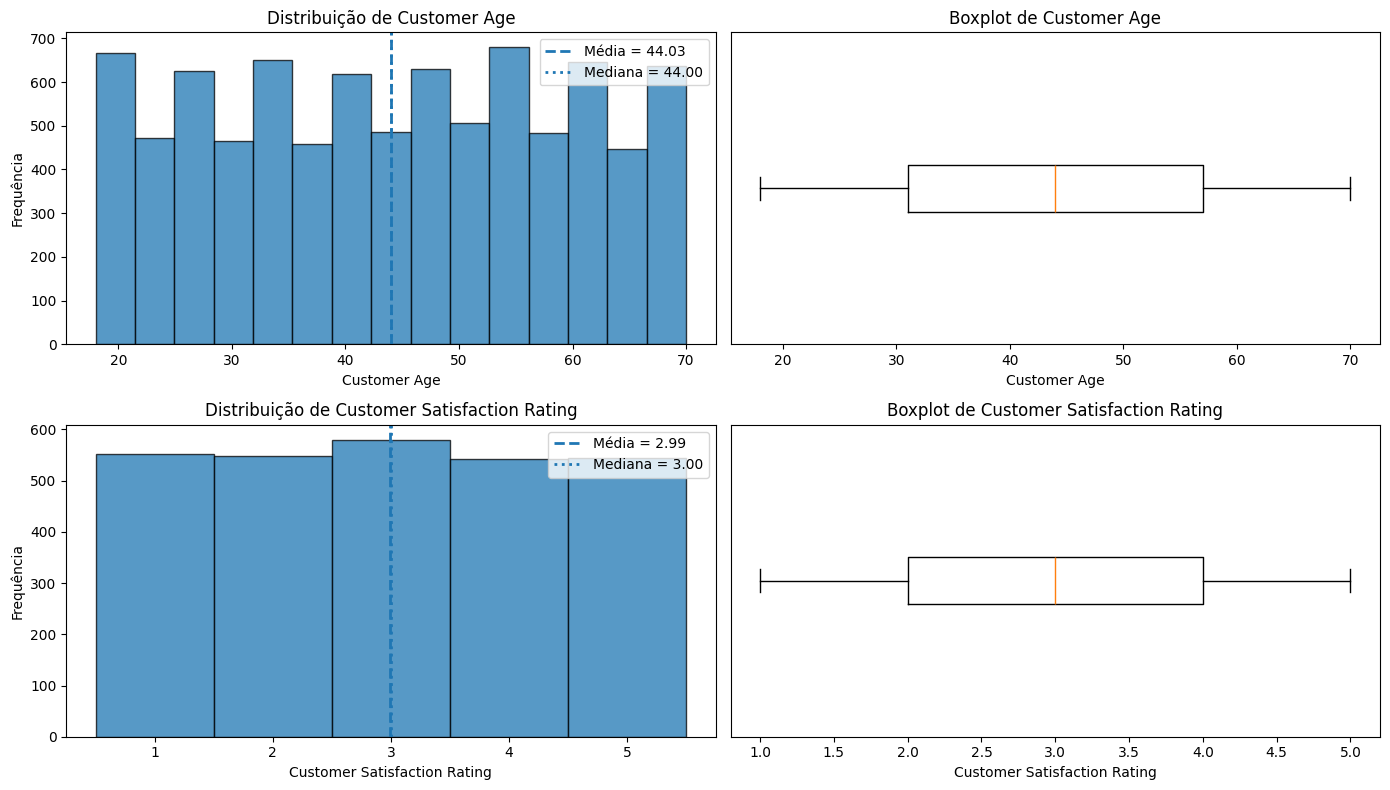

In [31]:
print_formatado("2. Distribuição das variáveis numéricas:")

fig, eixos = plt.subplots(nrows=len(colunas_numericas), ncols=2, figsize=(14, 4 * len(colunas_numericas)), squeeze=False)

for i, coluna in enumerate(colunas_numericas):
    dados = df[coluna].dropna()

    if coluna == "Customer Satisfaction Rating":
        bins = np.arange(0.5, 6, 1)
        eixos[i, 0].set_xticks(range(1,6))
    else:
        bins = 15

    eixos[i, 0].hist(dados, bins=bins, edgecolor="black", alpha=0.75)
    eixos[i, 0].axvline(dados.mean(), linestyle="--", linewidth=2, label=f"Média = {dados.mean():.2f}")
    eixos[i, 0].axvline(dados.median(), linestyle=":", linewidth=2, label=f"Mediana = {dados.median():.2f}")
    eixos[i, 0].set_title(f"Distribuição de {coluna}")
    eixos[i, 0].set_xlabel(coluna)
    eixos[i, 0].set_ylabel("Frequência")
    eixos[i, 0].legend()

    eixos[i, 1].boxplot(dados, orientation="horizontal")
    eixos[i, 1].set_title(f"Boxplot de {coluna}")
    eixos[i, 1].set_xlabel(coluna)
    eixos[i, 1].set_yticks([])
plt.tight_layout()
print("Ver Markdown")
plt.show()

## **Variáveis Categóricas**

### 3. Frequência das variáveis categóricas

In [32]:
print_formatado("3. Frequência das variáveis categóricas:")

for coluna in colunas_categoricas:
    frequencia_absoluta = df[coluna].value_counts()

    frequencia_relativa = (df[coluna].value_counts(normalize=True).mul(100).round(2))

    tabela_frequencia = pd.DataFrame({
        "Frequência absoluta": frequencia_absoluta,
        "Frequência relativa (%)": frequencia_relativa
    })

    categoria_mais_frequente = frequencia_absoluta.idxmax()

    print(f"\n{coluna}:")
    print(f"  quantidade de categorias: {df[coluna].nunique()}")
    print(
        f"  categoria mais frequente: {categoria_mais_frequente} "
        f"({frequencia_absoluta.loc[categoria_mais_frequente]} registros - "
        f"{frequencia_relativa.loc[categoria_mais_frequente]:.2f}%)"
    )

    display(tabela_frequencia)
    print("="*100)
print("Ver Markdown")



3. Frequência das variáveis categóricas:

Customer Gender:
  quantidade de categorias: 3
  categoria mais frequente: Male (2896 registros - 34.20%)


,Frequência absoluta,Frequência relativa (%)
Customer Gender,,
Male,2896,34.20
Female,2887,34.09
Other,2686,31.72



Product Purchased:
  quantidade de categorias: 42
  categoria mais frequente: Canon EOS (240 registros - 2.83%)


,Frequência absoluta,Frequência relativa (%)
Product Purchased,,
Canon EOS,240,2.83
GoPro Hero,228,2.69
Nest Thermostat,225,2.66
Philips Hue Lights,221,2.61
Amazon Echo,221,2.61
LG Smart TV,219,2.59
Sony Xperia,217,2.56
Roomba Robot Vacuum,216,2.55
Apple AirPods,213,2.52



Ticket Type:
  quantidade de categorias: 5
  categoria mais frequente: Refund request (1752 registros - 20.69%)


...


Ticket Priority:
  quantidade de categorias: 4
  categoria mais frequente: Medium (2192 registros - 25.88%)


,Frequência absoluta,Frequência relativa (%)
Ticket Priority,,
Medium,2192,25.88
Critical,2129,25.14
High,2085,24.62
Low,2063,24.36



Ticket Channel:
  quantidade de categorias: 4
  categoria mais frequente: Email (2143 registros - 25.30%)


,Frequência absoluta,Frequência relativa (%)
Ticket Channel,,
Email,2143,25.30
Phone,2132,25.17
Social media,2121,25.04
Chat,2073,24.48


Ver Markdown


### 4. Distribuição das variáveis categóricas



4. Distribuição das variáveis categóricas:


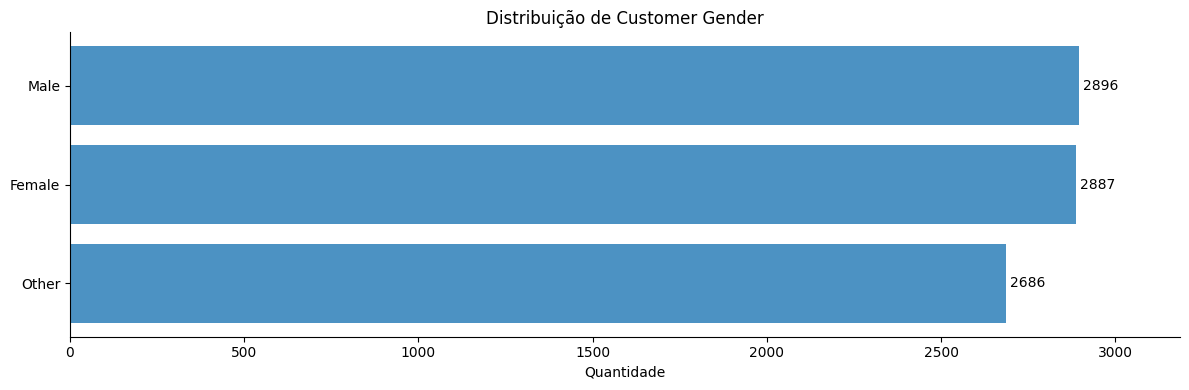

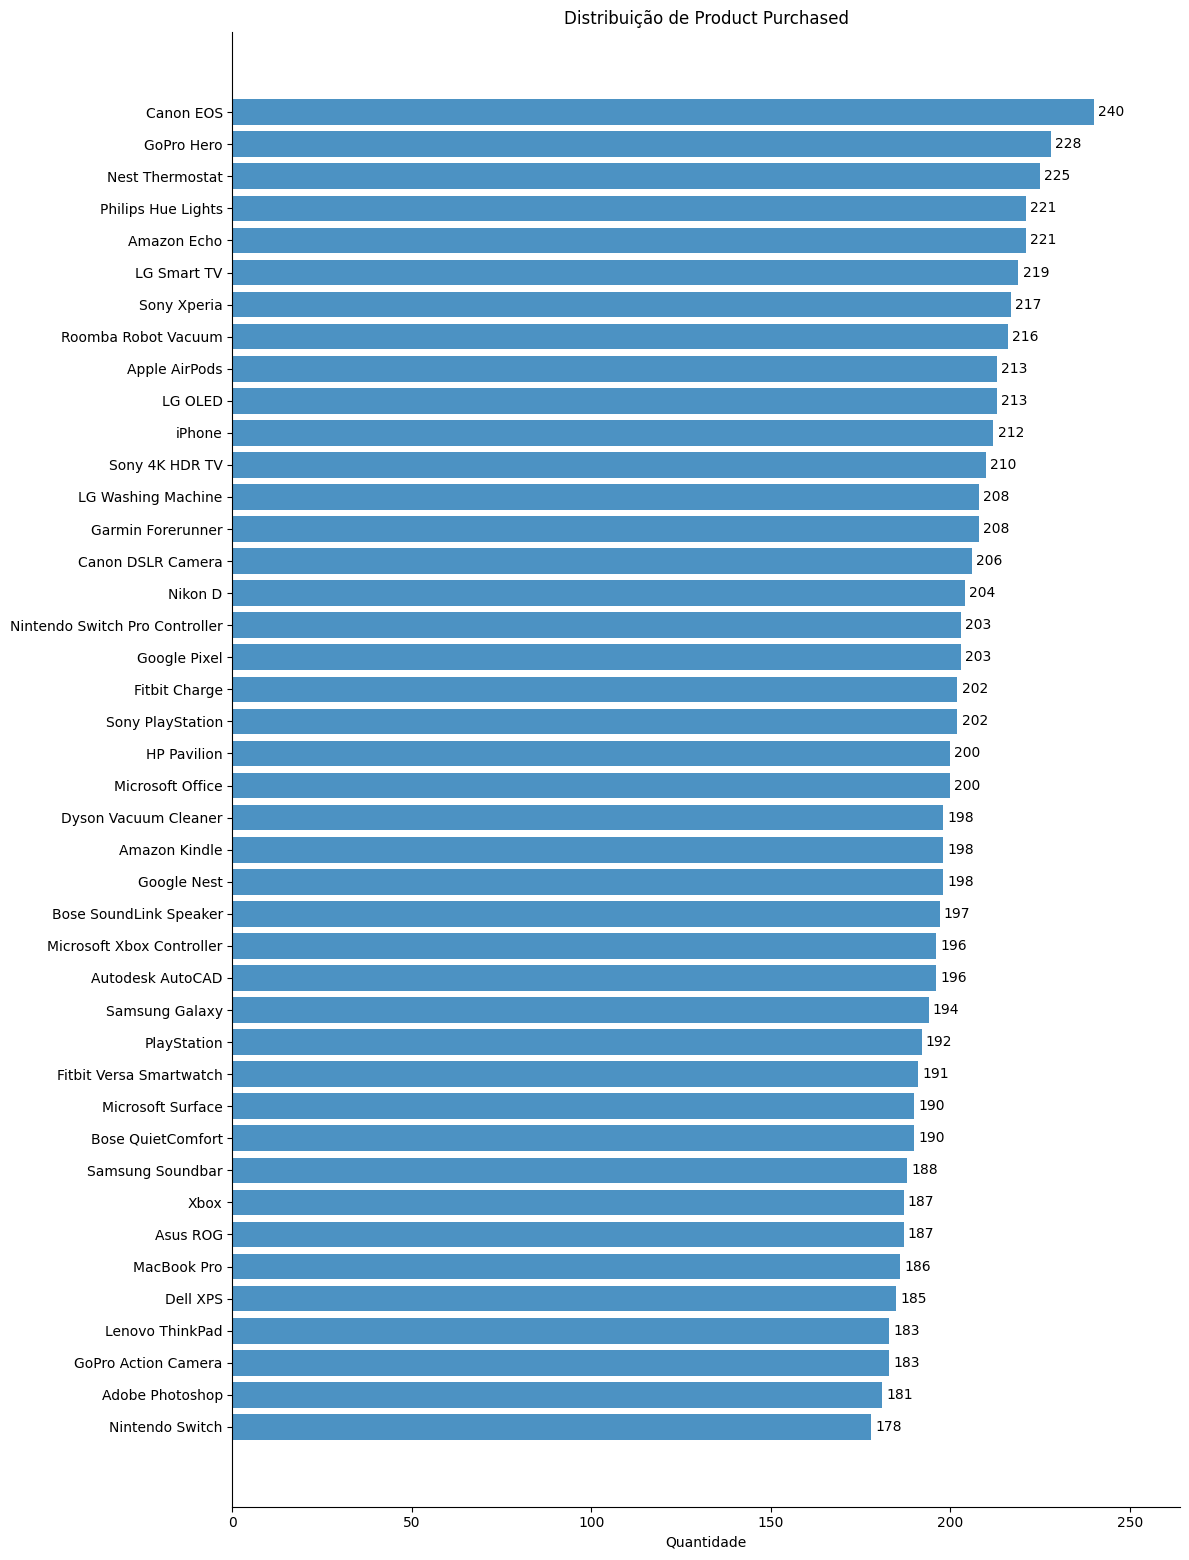

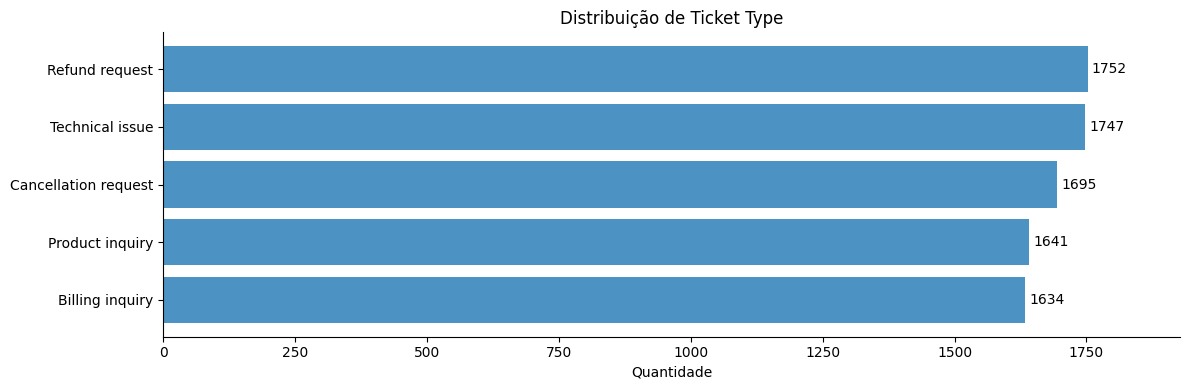

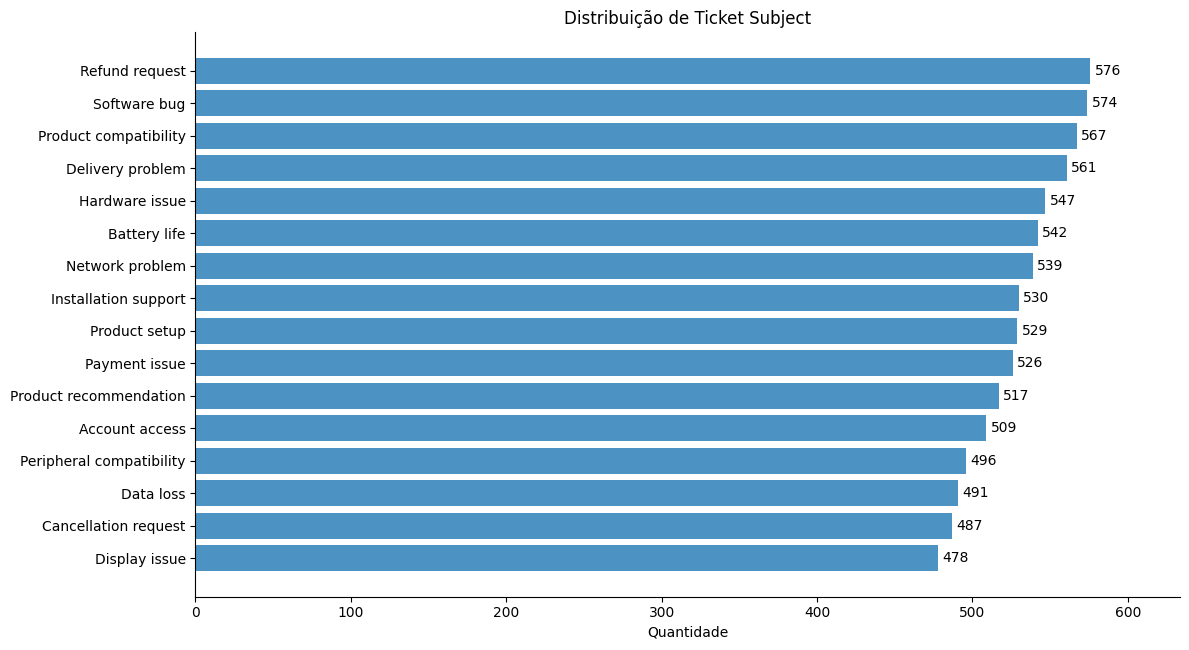

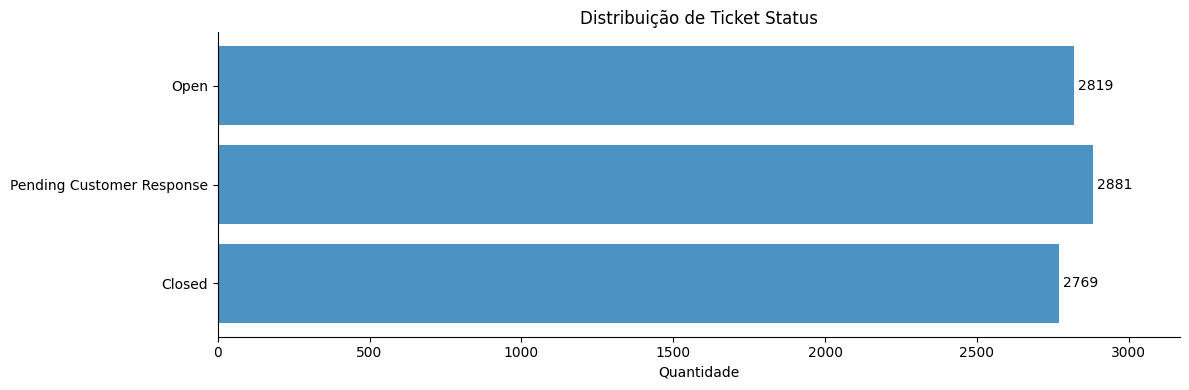

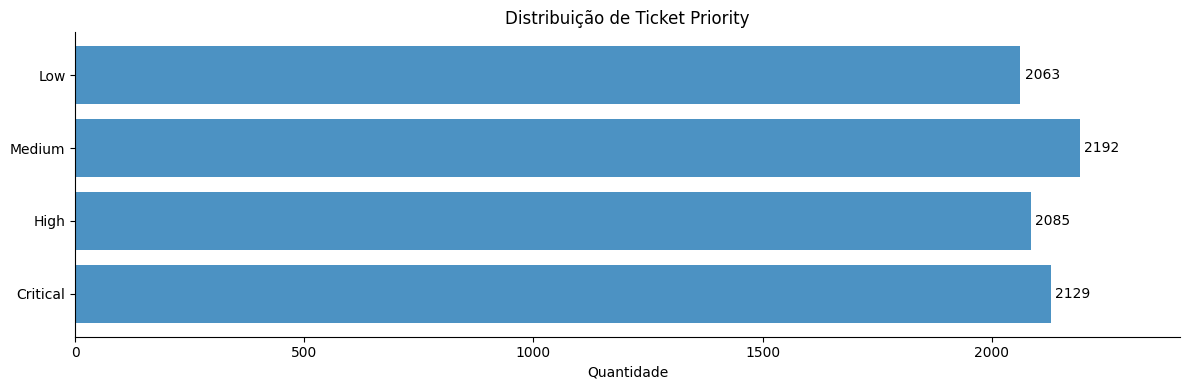

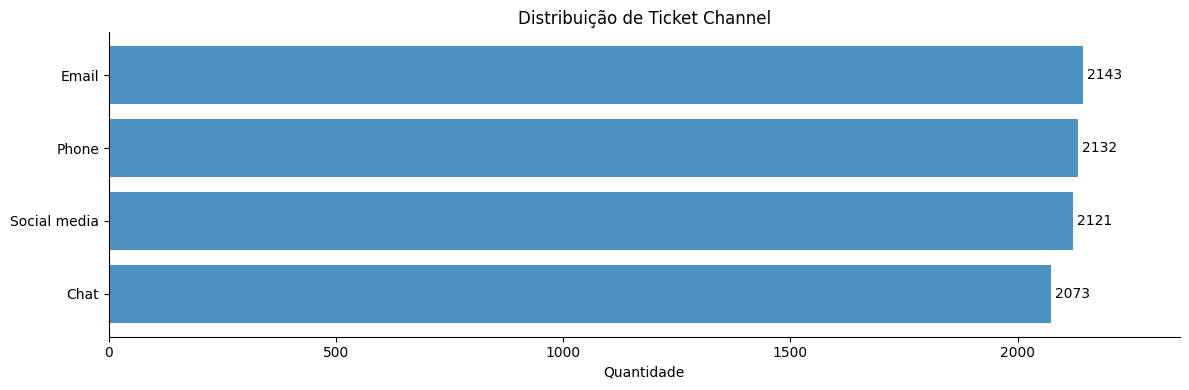

Ver Markdown


In [33]:
print_formatado("4. Distribuição das variáveis categóricas:")

ordens = {
    "Ticket Status": ["Open", "Pending Customer Response", "Closed"],
    "Ticket Priority": ["Low", "Medium", "High", "Critical"]
}

for coluna in colunas_categoricas:
    contagem = df[coluna].value_counts()

    if coluna in ordens:
        contagem = contagem.reindex(ordens[coluna])

    altura = max(4, 0.35 * len(contagem) + 1)

    fig, ax = plt.subplots(figsize=(12, altura))

    barras = ax.barh(contagem.index.astype(str), contagem.values, alpha=0.8)

    ax.bar_label(barras, fmt="%d", padding=3)

    ax.set_title(f"Distribuição de {coluna}")
    ax.set_xlabel("Quantidade")

    ax.invert_yaxis()

    ax.margins(x=0.1)

    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

    plt.tight_layout()
    plt.show()

print("Ver Markdown")

## **Observações Análise Univariada**

### 1. Estatísticas descritivas - Variáveis numéricas

* `Customer Age` varia de 18 a 70 anos, com média de 44,03 e mediana de 44 anos. O primeiro quartil é 31 e o terceiro quartil é 57, com desvio-padrão de 15,30.
* `Customer Satisfaction Rating` varia de 1 a 5, com média de 2,99 e mediana de 3. O primeiro quartil é 2 e o terceiro quartil é 4, com desvio-padrão de 1,41.
* A satisfação possui apenas 2.769 valores preenchidos, porque essa informação existe somente para tickets fechados. Os valores ausentes já foram identificados anteriormente como estruturais.

### 2. Distribuição das variáveis numéricas

* A distribuição de `Customer Age` é relativamente uniforme entre 18 e 70 anos. Média e mediana são praticamente iguais e o boxplot não indica valores discrepantes.
* `Customer Satisfaction Rating` também apresenta uma distribuição equilibrada entre as notas de 1 a 5, com média próxima de 3. O boxplot não mostra valores fora da escala esperada.
* A regularidade observada nas duas distribuições é compatível com a natureza do dataset.

### 3. Frequência das variáveis categóricas

* `Customer Gender` possui 3 categorias com frequências próximas. `Male` é a mais frequente, com 2.896 registros (34,20%).
* `Product Purchased` possui 42 categorias. `Canon EOS` é o produto mais frequente, com 240 registros (2,83%), mas nenhum produto apresenta concentração elevada.
* `Ticket Type`, nossa variável-alvo, possui 5 categorias bastante equilibradas. `Refund request` é a mais frequente, com 1.752 registros (20,69%), enquanto `Billing inquiry` é a menos frequente, com 1.634 (19,29%).
* `Ticket Subject` possui 16 categorias, também com frequências próximas. `Refund request` é o assunto mais frequente, com 576 registros (6,80%).
* `Ticket Status` possui 3 categorias equilibradas, sendo `Pending Customer Response` a mais frequente, com 2.881 registros (34,02%).
* `Ticket Priority` possui 4 categorias próximas de 25% cada. `Medium` é a mais frequente, com 2.192 registros (25,88%).
* `Ticket Channel` também possui 4 categorias bastante equilibradas. `Email` aparece com maior frequência, em 2.143 registros (25,30%).

### 4. Distribuição das variáveis categóricas

* Os gráficos confirmam que as variáveis categóricas apresentam, em geral, distribuições bastante equilibradas, sem uma única categoria dominando fortemente as demais.
* O equilíbrio de `Ticket Type` é especialmente importante para o problema de classificação, pois não há indício de desbalanceamento relevante entre as cinco classes da variável-alvo.
* `Product Purchased` apresenta alta cardinalidade, com 42 produtos, mas as ocorrências estão distribuídas de forma relativamente uniforme entre eles.
* `Ticket Subject` também possui quantidade maior de categorias, mas nenhuma delas concentra uma parcela muito elevada dos registros.
* O padrão de frequências próximas observado em diversas variáveis reforça novamente a característica sintética do dataset.

# **1.6 Análise Multivariada**




1.6 Análise Multivariada - Matriz de Correlação e Relações Bivariadas:


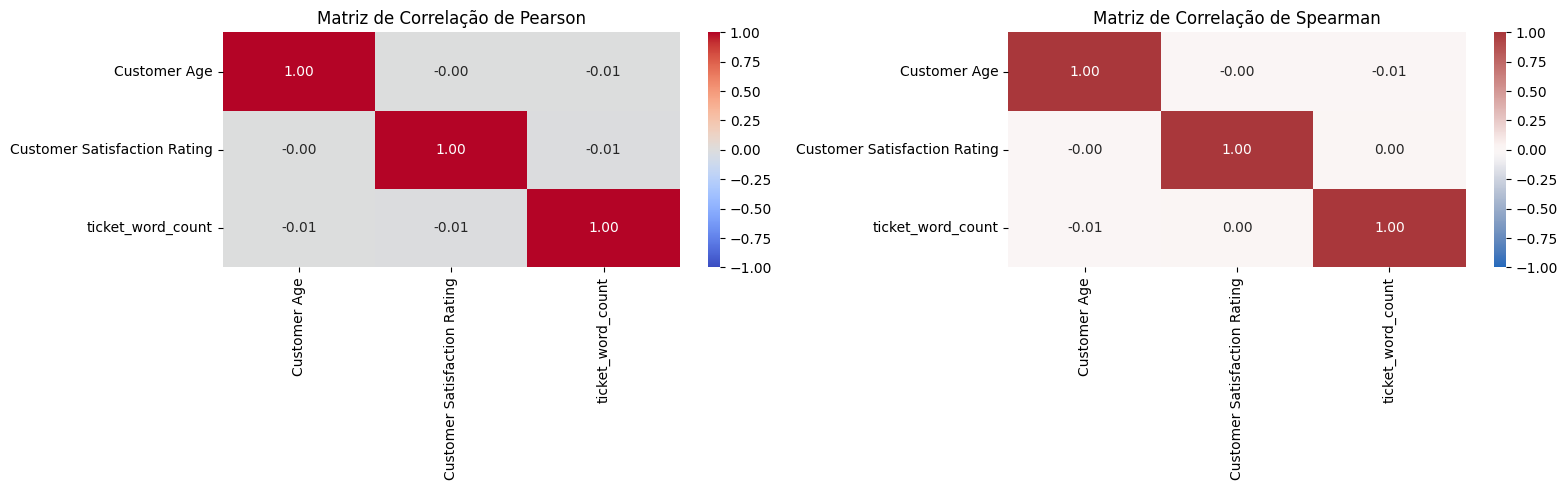

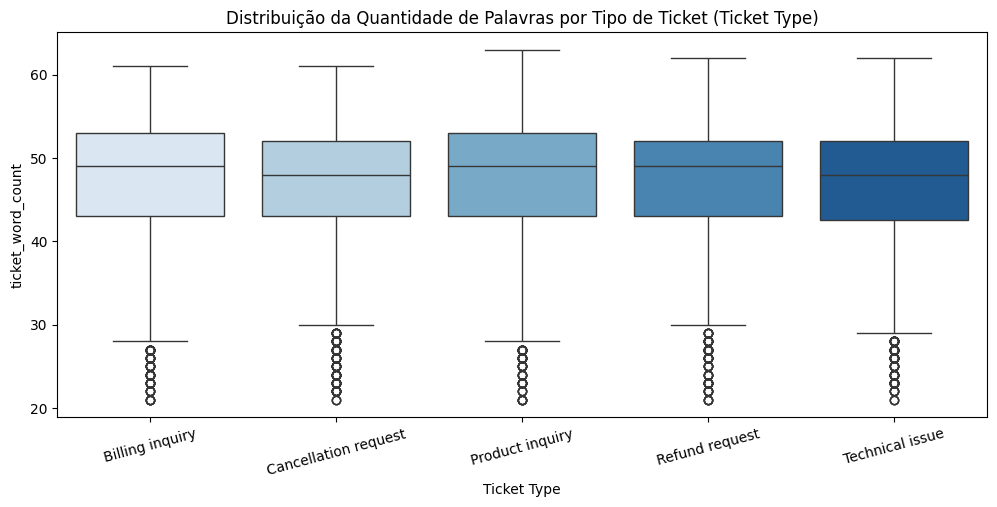

In [34]:
print_formatado("1.6 Análise Multivariada - Matriz de Correlação e Relações Bivariadas:")

colunas_num_analise = ["Customer Age", "Customer Satisfaction Rating", "ticket_word_count"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

corr_pearson = df[colunas_num_analise].corr(method="pearson")
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Matriz de Correlação de Pearson")

corr_spearman = df[colunas_num_analise].corr(method="spearman")
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Matriz de Correlação de Spearman")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df,
    x="Ticket Type",
    y="ticket_word_count",
    hue="Ticket Type",
    palette="Blues",
    legend=False,
)
plt.title("Distribuição da Quantidade de Palavras por Tipo de Ticket (Ticket Type)")
plt.xticks(rotation=15)
plt.show()

# **1.7 Identificação de Outliers e Anomalias**

In [35]:
print_formatado("1.7 Identificação de Outliers nas Variáveis Contínuas (Método IQR):")

for col in ["Customer Age", "ticket_word_count"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)]
    print(f"{col}:")
    print(f"  limite inferior: {lim_inf:.2f} | limite superior: {lim_sup:.2f}")
    print(f"  quantidade de outliers: {len(outliers)} ({len(outliers) / len(df) * 100:.2f}%)\n")



1.7 Identificação de Outliers nas Variáveis Contínuas (Método IQR):
Customer Age:
  limite inferior: -8.00 | limite superior: 96.00
  quantidade de outliers: 0 (0.00%)

ticket_word_count:
  limite inferior: 29.50 | limite superior: 65.50
  quantidade de outliers: 555 (6.55%)



# **1.8 Documentação do EDA e Conclusões**

### Hipóteses

Com base nos padrões observados durante a análise, foram definidas duas hipóteses para serem testadas estatisticamente:

* **Hipótese 1:** A prioridade do ticket (`Ticket Priority`) está relacionada à quantidade de palavras na descrição (`ticket_word_count`), sendo comparados os grupos `Critical` e `Low`.

* **Hipótese 2:** O tipo de ticket (`Ticket Type`) está relacionado à quantidade de palavras na descrição (`ticket_word_count`), sendo comparados os grupos `Technical issue` e `Billing inquiry`.

### Testes de Hipótese

Foi utilizado o teste de Mann-Whitney U, com nível de significância de 5%.

* **Hipótese 1:** O teste apresentou `p = 0,5774`. Portanto, não há evidência suficiente para rejeitar a hipótese nula.

* **Hipótese 2:** O teste apresentou `p = 0,4536`. Portanto, não há evidência suficiente para rejeitar a hipótese nula.

### Conclusões

As variáveis numéricas analisadas apresentaram correlações baixas. Os testes realizados também não encontraram diferenças estatisticamente significativas entre os grupos analisados.

O dataset foi suficiente para realizar o EDA proposto, mas foram encontradas algumas limitações nas descrições dos tickets, principalmente pela presença de marcadores não preenchidos.


In [36]:
print_formatado("1.8 Testes de Hipótese Formais com scipy.stats:")

grupo_critical = df[df["Ticket Priority"] == "Critical"]["ticket_word_count"]
grupo_low = df[df["Ticket Priority"] == "Low"]["ticket_word_count"]

u_stat1, p_val1 = stats.mannwhitneyu(
    grupo_critical, grupo_low, alternative="two-sided"
)

print("Hipótese 1: Quantidade de Palavras por Prioridade (Critical vs Low)")
print(f"Estatística U = {u_stat1:.2f} | p-valor = {p_val1:.4f}")
if p_val1 < 0.05:
  print(
      f"Decisão: Rejeita H0 (p={p_val1:.4f}) -> Há evidência estatística de"
      " diferença."
  )
else:
  print(
      f"Decisão: Não rejeita H0 (p={p_val1:.4f}) -> Não há evidência suficiente"
      " de diferença entre os grupos."
  )


grupo_tech = df[df["Ticket Type"] == "Technical issue"]["ticket_word_count"]
grupo_billing = df[df["Ticket Type"] == "Billing inquiry"]["ticket_word_count"]

u_stat2, p_val2 = stats.mannwhitneyu(
    grupo_tech, grupo_billing, alternative="two-sided"
)

print()

print(
    "Hipótese 2: Quantidade de Palavras por Tipo de Chamado (Technical issue vs"
    " Billing inquiry)"
)
print(f"Estatística U = {u_stat2:.2f} | p-valor = {p_val2:.4f}")
if p_val2 < 0.05:
  print(
      f"Decisão: Rejeita H0 (p={p_val2:.4f}) -> Há diferença estatisticamente"
      " significativa."
  )
else:
  print(
      f"Decisão: Não rejeita H0 (p={p_val2:.4f}) -> Não há evidência suficiente"
      " de diferença entre os grupos."
  )



1.8 Testes de Hipótese Formais com scipy.stats:
Hipótese 1: Quantidade de Palavras por Prioridade (Critical vs Low)
Estatística U = 2217869.50 | p-valor = 0.5774
Decisão: Não rejeita H0 (p=0.5774) -> Não há evidência suficiente de diferença entre os grupos.

Hipótese 2: Quantidade de Palavras por Tipo de Chamado (Technical issue vs Billing inquiry)
Estatística U = 1406066.50 | p-valor = 0.4536
Decisão: Não rejeita H0 (p=0.4536) -> Não há evidência suficiente de diferença entre os grupos.
